# Quantum vs Classical — where do they diverge?

A single deterministic 10-track event, solved both classically and with **1BQF**
(1-bit quantum filter, the same routine used in `condor_obqf/run_event.py`).
Goal: understand why segment efficiency for Q is already < 100 % at small
$T$, even though the classical solve recovers all true segments.

We will:

1. Generate one fixed 10-track event locally (CPU only, no condor).
2. Build the §14 Hamiltonian $A x = b$ on doublet segments.
3. Solve classically and with 1BQF.
4. Compare the two solution vectors element by element, broken down by
   segment truth (true / false segment).
5. Look at the activation decision at $\tau = 0.35$ as a confusion matrix.
6. Sweep $\tau$ to see whether Q is just biased / mis-scaled.
7. Project both solutions onto the eigenbasis of $A$ to see which
   eigencomponents 1BQF mis-inverts (1 time qubit ⇒ very coarse $\lambda$
   resolution).
8. Sweep shots to separate stochastic noise from deterministic bias.


In [2]:
## 1. Imports — match the condor worker exactly

import sys, time, copy
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from collections import defaultdict

# lhcb_velo_toy
from lhcb_velo_toy.solvers.hamiltonians.fast import SimpleHamiltonianFast
from lhcb_velo_toy.solvers.quantum.one_bit_hhl import OneBitHHL
from lhcb_velo_toy.solvers.reconstruction.track_finder import (
    get_tracks, get_tracks_layered,
)
from lhcb_velo_toy.analysis.validation.validator import EventValidator
from lhcb_velo_toy.generation.generators.state_event import StateEventGenerator
from lhcb_velo_toy.generation.geometry.plane import PlaneGeometry

# qiskit
from qiskit_aer import AerSimulator
from qiskit import transpile

print("python:", sys.version.split()[0])
import qiskit, qiskit_aer
print("qiskit:", qiskit.__version__, "aer:", qiskit_aer.__version__)


python: 3.12.11
qiskit: 2.2.0 aer: 0.17.2


In [9]:
## 2. Event parameters — frozen to the §14 / condor recipe

N_TRK       = 10
REP         = 0          # determines seed
SHOTS       = 1e4
DEVICE      = 'CPU'      # local — no GPU needed at T=10
DROP_RATE   = 0.0

# Hamiltonian / segment params
EPSILON     = 2e-3       # rad — angular cut on segment-segment compatibility
GAMMA       = 3.0
DELTA       = 1.0
THRESHOLD   = 0.35       # τ used in §14 segment metrics

# Detector + smearing
SIGMA_RES   = 0.005      # mm
SIGMA_SCATT = 1e-4
N_MODULES   = 5
DZ_MM       = 33.0

# 1BQF
NUM_TIME_QUBITS = 1

SEED = REP + N_TRK * 100 + 140000
print(f"seed = {SEED}")


seed = 141000


In [10]:
## 3. Generate one fixed 10-track event

# Helpers cloned verbatim from condor_obqf/run_event.py so the event matches
# the production pipeline.

def safe_generate(n_trk, measurement_error, collision_noise,
                  n_modules=N_MODULES, dz_mm=DZ_MM, max_attempts=20,
                  phi_max=0.2, theta_max=0.2):
    HALF_X, HALF_Y, Z_FIRST = 40.0, 40.0, 33.0
    PV_SIGMA = {"x": 0, "y": 0, "z": 1}
    z_pos = [Z_FIRST + i * dz_mm for i in range(n_modules)]
    geo = PlaneGeometry(module_id=list(range(n_modules)),
                        lx=[HALF_X]*n_modules, ly=[HALF_Y]*n_modules, z=z_pos)
    last = None
    for _ in range(max_attempts):
        gen = StateEventGenerator(
            detector_geometry=geo, events=1, n_particles=[n_trk],
            phi_min=-phi_max, phi_max=phi_max,
            theta_min=-theta_max, theta_max=theta_max,
            measurement_error=measurement_error,
            collision_noise=collision_noise,
        )
        gen.generate_random_primary_vertices(PV_SIGMA)
        gen.generate_particles([[{"type":"pion","mass":139.6,"q":1}]*n_trk])
        ev = gen.generate_complete_events()
        last = ev
        if ev is not None and ev.tracks and \
           min(len(t.hit_ids) for t in ev.tracks) >= 3:
            return ev
    return last

np.random.seed(SEED)
ev = safe_generate(N_TRK, SIGMA_RES, SIGMA_SCATT)
print(f"event: {len(ev.tracks)} tracks, {len(ev.hits)} hits")
for i, t in enumerate(ev.tracks):
    print(f"  track {i:2d}: track_id={t.track_id} n_hits={len(t.hit_ids)}")


event: 10 tracks, 50 hits
  track  0: track_id=0 n_hits=5
  track  1: track_id=1 n_hits=5
  track  2: track_id=2 n_hits=5
  track  3: track_id=3 n_hits=5
  track  4: track_id=4 n_hits=5
  track  5: track_id=5 n_hits=5
  track  6: track_id=6 n_hits=5
  track  7: track_id=7 n_hits=5
  track  8: track_id=8 n_hits=5
  track  9: track_id=9 n_hits=5


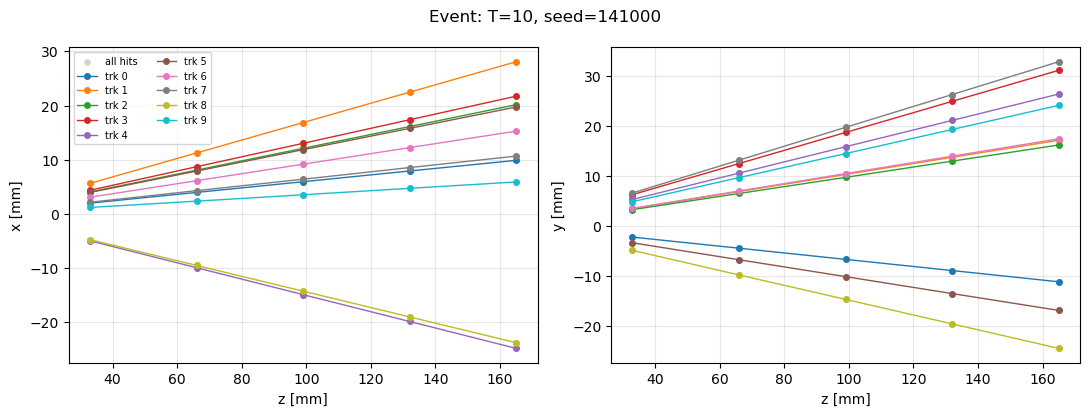

In [11]:
## 4. Visualise the event (z–x and z–y projections, true tracks coloured)

hit_x = np.array([h.x for h in ev.hits])
hit_y = np.array([h.y for h in ev.hits])
hit_z = np.array([h.z for h in ev.hits])
hid_to_idx = {h.hit_id: i for i, h in enumerate(ev.hits)}

cmap = plt.cm.tab10
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
for ax, ycoord, ylab in [(axes[0], hit_x, 'x [mm]'), (axes[1], hit_y, 'y [mm]')]:
    ax.scatter(hit_z, ycoord, s=14, c='lightgray', zorder=1, label='all hits')
    for i, t in enumerate(ev.tracks):
        idx = [hid_to_idx[hid] for hid in t.hit_ids if hid in hid_to_idx]
        if not idx: continue
        order = np.argsort(hit_z[idx])
        idx = np.array(idx)[order]
        ax.plot(hit_z[idx], ycoord[idx], '-o', ms=4, lw=1, color=cmap(i % 10),
                label=f'trk {i}' if ax is axes[0] else None)
    ax.set_xlabel('z [mm]'); ax.set_ylabel(ylab); ax.grid(alpha=.3)
axes[0].legend(fontsize=7, ncol=2, loc='upper left')
fig.suptitle(f'Event: T={N_TRK}, seed={SEED}')
fig.tight_layout(); plt.show()


In [12]:
## 5. Build doublet segments and the §14 Hamiltonian

# Use the package implementation directly. SimpleHamiltonianFast.construct_hamiltonian
# does the same job as the old in-notebook helper:
#   - groups segments by adjacent module pairs
#   - applies the angular cut (or ERF if convolution=True)
#   - returns A in CSC with sign convention A = (γ+δ)I − C, b = δ·1
ham = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA)
ham.construct_hamiltonian(ev, convolution=False)

n_seg = ham.n_segments
A_dense = ham.A.toarray()
b = np.asarray(ham.b).ravel()
print(f"n_seg = {n_seg}")
print(f"A: {A_dense.shape}, sym err = {np.max(np.abs(A_dense - A_dense.T)):.2e}")
print(f"diag = {np.unique(np.diag(A_dense))}")
print(f"|off-diag| nonzero count = {(A_dense != 0).sum() - n_seg}")


n_seg = 400
A: (400, 400), sym err = 0.00e+00
diag = [4.]
|off-diag| nonzero count = 60


In [13]:
## 6. Truth labels for each segment + the segment-building efficiency

# Truth segment ⇔ both endpoints belong to the same real track
seg_truth = np.array([
    s.hit_start.track_id == s.hit_end.track_id and s.hit_start.track_id >= 0
    for s in ham.segments
])
n_true = int(seg_truth.sum())
n_false = n_seg - n_true

# How many of the truth-possible segments did the builder actually create?
# (Each track contributes (n_layers_hit - 1) doublets in the §14 layered build.)
truth_possible = sum(max(len(t.hit_ids) - 1, 0) for t in ev.tracks)
print(f"segments built : {n_seg}")
print(f"  truth        : {n_true}")
print(f"  fake         : {n_false}")
print(f"truth-possible : {truth_possible}  (Σ (n_hits-1) over tracks)")
print(f"build eff      : {n_true / truth_possible:.3f}")


segments built : 400
  truth        : 40
  fake         : 360
truth-possible : 40  (Σ (n_hits-1) over tracks)
build eff      : 1.000


λ_min = 2.3820  λ_max = 5.6180
κ(A)  = 2.36
distinct eigenvalues (rounded 4dp): 5


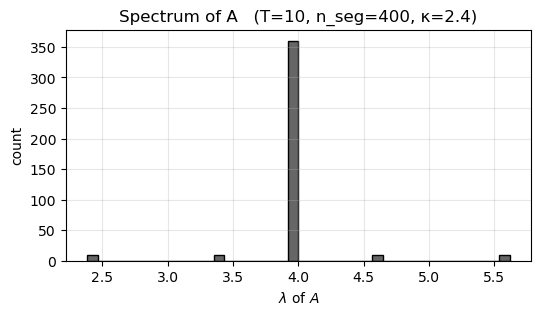

In [14]:
## 7. Inspect the spectrum of A — what does 1BQF have to invert?

eigvals, eigvecs = np.linalg.eigh(A_dense)   # A is symmetric
kappa = eigvals.max() / max(eigvals.min(), 1e-12)
print(f"λ_min = {eigvals.min():.4f}  λ_max = {eigvals.max():.4f}")
print(f"κ(A)  = {kappa:.2f}")
print(f"distinct eigenvalues (rounded 4dp): {len(set(np.round(eigvals,4)))}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(eigvals, bins=40, color='#666', edgecolor='k')
ax.set_xlabel(r'$\lambda$ of $A$'); ax.set_ylabel('count'); ax.grid(alpha=.3)
ax.set_title(f'Spectrum of A   (T={N_TRK}, n_seg={n_seg}, κ={kappa:.1f})')
plt.show()


In [15]:
## 8. Solve classically and with 1BQF (CPU, single shot of statistics)

# --- classical
t0 = time.time()
sol_C = ham.solve_classicaly()
t_C = time.time() - t0

# --- 1BQF
t0 = time.time()
hhl = OneBitHHL(A_dense, b, num_time_qubits=NUM_TIME_QUBITS,
                shots=SHOTS, debug=False)
hhl.build_circuit()
sim = AerSimulator(method='statevector', device=DEVICE)
tqc = transpile(hhl.circuit, sim, optimization_level=1)
hhl.counts = sim.run(tqc, shots=SHOTS).result().get_counts()
sol_Q_raw, n_success = hhl.get_solution()
t_Q = time.time() - t0

# Classical-norm rescaling (same as run_event.py)
nC = np.linalg.norm(sol_C); nQ = np.linalg.norm(sol_Q_raw)
sol_Q = sol_Q_raw * (nC / nQ) if nQ > 0 else np.zeros_like(sol_Q_raw)

print(f"classical: {t_C*1000:.1f} ms,  ‖sol_C‖={nC:.3f}")
print(f"1BQF     : {t_Q:.2f} s, success_prob={n_success/SHOTS:.3f}, "
      f"‖sol_Q_raw‖={nQ:.3f}")
print(f"cos(C,Q)        = {np.dot(sol_C, sol_Q_raw)/(nC*nQ):.4f}")
print(f"‖sol_C - sol_Q‖ = {np.linalg.norm(sol_C - sol_Q):.3f}  "
      f"(rel = {np.linalg.norm(sol_C - sol_Q)/nC:.3f})")


classical: 0.7 ms,  ‖sol_C‖=5.411
1BQF     : 0.95 s, success_prob=0.023, ‖sol_Q_raw‖=1.000
cos(C,Q)        = 0.4498
‖sol_C - sol_Q‖ = 5.676  (rel = 1.049)


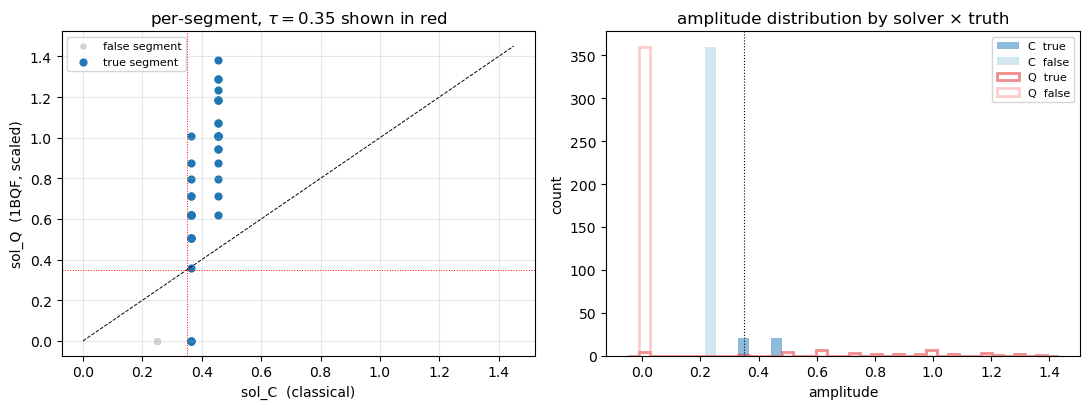

In [16]:
## 9. Element-wise comparison of sol_C vs sol_Q

# scatter coloured by truth label, plus per-bucket histogram
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
mT, mF = seg_truth, ~seg_truth
ax.scatter(sol_C[mF], sol_Q[mF], s=14, c='lightgray', label='false segment')
ax.scatter(sol_C[mT], sol_Q[mT], s=24, c='#1f78b4', label='true segment')
lim = max(sol_C.max(), sol_Q.max(), 1.0) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=.7)
ax.axhline(THRESHOLD, color='r', lw=.7, ls=':')
ax.axvline(THRESHOLD, color='r', lw=.7, ls=':')
ax.set_xlabel('sol_C  (classical)')
ax.set_ylabel('sol_Q  (1BQF, scaled)')
ax.set_title(rf'per-segment, $\tau={THRESHOLD}$ shown in red')
ax.legend(fontsize=8); ax.grid(alpha=.3)

ax = axes[1]
bins = np.linspace(min(sol_C.min(), sol_Q.min()) - 0.05,
                   max(sol_C.max(), sol_Q.max()) + 0.05, 40)
ax.hist(sol_C[mT], bins=bins, alpha=.5, color='#1f78b4', label='C  true')
ax.hist(sol_C[mF], bins=bins, alpha=.5, color='#a6cee3', label='C  false')
ax.hist(sol_Q[mT], bins=bins, alpha=.5, color='#e31a1c',
        label='Q  true', histtype='step', lw=2)
ax.hist(sol_Q[mF], bins=bins, alpha=.5, color='#fb9a99',
        label='Q  false', histtype='step', lw=2)
ax.axvline(THRESHOLD, color='k', ls=':', lw=.8)
ax.set_xlabel('amplitude'); ax.set_ylabel('count'); ax.legend(fontsize=8)
ax.set_title('amplitude distribution by solver × truth')
fig.tight_layout(); plt.show()


In [17]:
## 10. Confusion matrix of the τ=0.35 activation decisions

import pandas as pd

actC = sol_C > THRESHOLD
actQ = sol_Q > THRESHOLD

def label(t, a):  # truth, active
    return f"{'true' if t else 'false'} / {'on' if a else 'off'}"

records = []
for i in range(n_seg):
    records.append(dict(
        seg=i, truth=bool(seg_truth[i]),
        sol_C=float(sol_C[i]), sol_Q=float(sol_Q[i]),
        on_C=bool(actC[i]), on_Q=bool(actQ[i]),
    ))
df = pd.DataFrame.from_records(records)

print("=== activation confusion (rows: classical, cols: quantum) ===")
print(pd.crosstab(df.on_C.map({True:'C on', False:'C off'}),
                  df.on_Q.map({True:'Q on', False:'Q off'}),
                  margins=True))

print("\n=== activation × truth (rows: solver|state, cols: truth) ===")
for name, act in [('C', actC), ('Q', actQ)]:
    tp = int(((seg_truth) & act).sum())
    fn = int(((seg_truth) & ~act).sum())
    fp = int((~seg_truth & act).sum())
    tn = int((~seg_truth & ~act).sum())
    eff = tp / max(tp + fn, 1)
    pur = tp / max(tp + fp, 1)
    print(f"  {name}: TP={tp:3d}  FN={fn:3d}  FP={fp:3d}  TN={tn:3d}   "
          f"eff={eff:.3f}  pur={pur:.3f}")

# focus: true segments that Q misses
miss = df[(df.truth) & (~df.on_Q)].sort_values('sol_Q')
print(f"\n=== {len(miss)} TRUE segments that Q drops below τ={THRESHOLD} ===")
print(miss[['seg','sol_C','sol_Q','on_C']].to_string(index=False))

# fakes that Q activates but C doesn't
fakes = df[(~df.truth) & (df.on_Q) & (~df.on_C)].sort_values('sol_Q', ascending=False)
print(f"\n=== {len(fakes)} FAKE segments Q turns on but C does not ===")
print(fakes.head(20)[['seg','sol_C','sol_Q','truth']].to_string(index=False))


=== activation confusion (rows: classical, cols: quantum) ===
on_Q   Q off  Q on  All
on_C                   
C off    360     0  360
C on       4    36   40
All      364    36  400

=== activation × truth (rows: solver|state, cols: truth) ===
  C: TP= 40  FN=  0  FP=  0  TN=360   eff=1.000  pur=1.000
  Q: TP= 36  FN=  4  FP=  0  TN=360   eff=0.900  pur=1.000

=== 4 TRUE segments that Q drops below τ=0.35 ===
 seg    sol_C  sol_Q  on_C
  11 0.363636    0.0  True
 322 0.363636    0.0  True
 355 0.363636    0.0  True
 366 0.363636    0.0  True

=== 0 FAKE segments Q turns on but C does not ===
Empty DataFrame
Columns: [seg, sol_C, sol_Q, truth]
Index: []


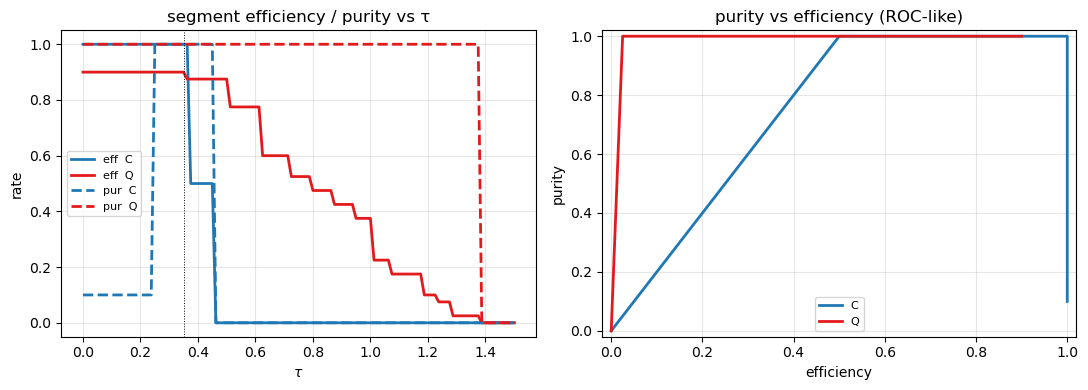

argmax(effQ * purQ) at τ = 0.000  (effQ=0.900, purQ=1.000)


In [18]:
## 11. Threshold sweep — is the gap a thresholding artefact?

# If sol_Q is just sol_C shifted/rescaled, the optimal Q threshold should sit
# at a different place. Plot eff/purity vs τ for both.

taus = np.linspace(0.0, 1.5, 121)
def metrics(sol):
    eff, pur, ghost = [], [], []
    for t in taus:
        a = sol > t
        tp = int((seg_truth & a).sum())
        fn = int((seg_truth & ~a).sum())
        fp = int((~seg_truth & a).sum())
        eff.append(tp / max(tp+fn, 1))
        pur.append(tp / max(tp+fp, 1))
        ghost.append(fp / max(a.sum(), 1))
    return np.array(eff), np.array(pur), np.array(ghost)

effC, purC, gC = metrics(sol_C)
effQ, purQ, gQ = metrics(sol_Q)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(taus, effC, color='#1f78b4', lw=2, label='eff  C')
ax[0].plot(taus, effQ, color='#e31a1c', lw=2, label='eff  Q')
ax[0].plot(taus, purC, color='#1f78b4', lw=2, ls='--', label='pur  C')
ax[0].plot(taus, purQ, color='#e31a1c', lw=2, ls='--', label='pur  Q')
ax[0].axvline(THRESHOLD, color='k', ls=':', lw=.7)
ax[0].set_xlabel(r'$\tau$'); ax[0].set_ylabel('rate')
ax[0].set_title('segment efficiency / purity vs τ')
ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)

ax[1].plot(effC, purC, color='#1f78b4', lw=2, label='C')
ax[1].plot(effQ, purQ, color='#e31a1c', lw=2, label='Q')
ax[1].set_xlabel('efficiency'); ax[1].set_ylabel('purity')
ax[1].set_title('purity vs efficiency (ROC-like)')
ax[1].grid(alpha=.3); ax[1].legend(fontsize=8)
ax[1].set_xlim(-0.02, 1.02); ax[1].set_ylim(-0.02, 1.02)
fig.tight_layout(); plt.show()

# Best τ for Q
best_t = taus[np.argmax(effQ * purQ)]
print(f"argmax(effQ * purQ) at τ = {best_t:.3f}  "
      f"(effQ={effQ[np.argmax(effQ*purQ)]:.3f}, purQ={purQ[np.argmax(effQ*purQ)]:.3f})")


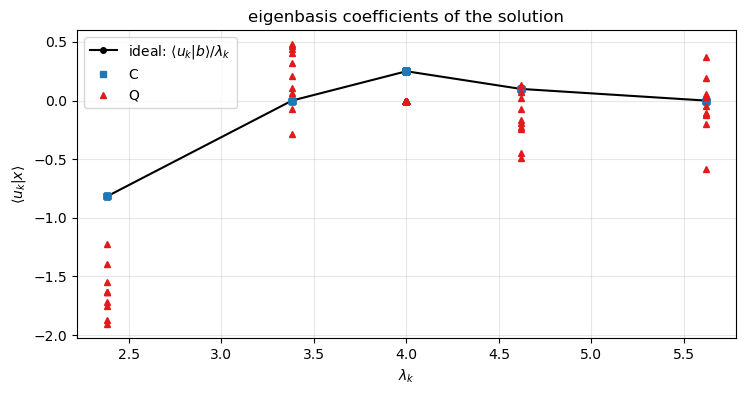

per-eigenmode errors  (sorted by |err_Q|, top 10):
         λ      ideal      coefC      coefQ      err_Q
    2.3820    -0.8172    -0.8172    -1.9080    -1.0908
    2.3820    -0.8172    -0.8172    -1.8673    -1.0502
    2.3820    -0.8172    -0.8172    -1.7508    -0.9336
    2.3820    -0.8172    -0.8172    -1.7167    -0.8995
    2.3820    -0.8172    -0.8172    -1.6361    -0.8189
    2.3820    -0.8172    -0.8172    -1.6313    -0.8141
    2.3820    -0.8172    -0.8172    -1.6289    -0.8117
    2.3820    -0.8172    -0.8172    -1.5485    -0.7313
    4.6180     0.0995     0.0995    -0.4889    -0.5884
    5.6180     0.0000     0.0000    -0.5811    -0.5811


In [19]:
## 12. Eigenbasis projection — *which* eigencomponents does 1BQF mis-invert?

# x = A^{-1} b = Σ_k (u_k · b) / λ_k · u_k
# Project sol_C and sol_Q onto eigvecs and compare component magnitudes.
coefC = eigvecs.T @ sol_C
coefQ = eigvecs.T @ sol_Q
coefb = eigvecs.T @ b
ideal = coefb / eigvals       # exact A^-1 b coefficients in eigenbasis

fig, ax = plt.subplots(figsize=(8.5, 4))
order = np.argsort(eigvals)
ax.plot(eigvals[order], ideal[order],  'o-', ms=4, color='k',
        label=r'ideal: $\langle u_k|b\rangle/\lambda_k$')
ax.plot(eigvals[order], coefC[order],  's',  ms=5, color='#1f78b4', label='C')
ax.plot(eigvals[order], coefQ[order],  '^',  ms=5, color='#e31a1c', label='Q')
ax.set_xlabel(r'$\lambda_k$'); ax.set_ylabel(r'$\langle u_k | x\rangle$')
ax.set_title('eigenbasis coefficients of the solution')
ax.grid(alpha=.3); ax.legend()
plt.show()

# Per-eigenmode "inversion error" relative to ideal
err_C = coefC - ideal
err_Q = coefQ - ideal
print("per-eigenmode errors  (sorted by |err_Q|, top 10):")
idx_top = np.argsort(-np.abs(err_Q))[:10]
print(f"{'λ':>10} {'ideal':>10} {'coefC':>10} {'coefQ':>10} {'err_Q':>10}")
for k in idx_top:
    print(f"{eigvals[k]:10.4f} {ideal[k]:10.4f} "
          f"{coefC[k]:10.4f} {coefQ[k]:10.4f} {err_Q[k]:+10.4f}")


 shots  succ_prob    cos  rel_l2   effQ
  1024     0.0322 0.3574  1.1337 0.5500
  4096     0.0239 0.4112  1.0852 0.7500
  8192     0.0209 0.4330  1.0648 0.8750
 32768     0.0233 0.4609  1.0384 0.9250


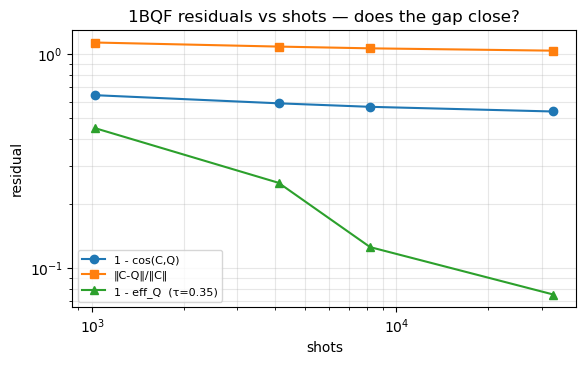

In [20]:
## 13. Shots sweep — stochastic noise vs deterministic bias

# If the gap shrinks ∝ 1/√shots, it's just sampling noise.
# If it plateaus, the residual is the deterministic bias of the
# 1-time-qubit eigenvalue inversion (and the post-selection scaling).

shots_grid = [1024, 4096, 8192, 32768]
sims = AerSimulator(method='statevector', device=DEVICE)

rows = []
for s in shots_grid:
    h = OneBitHHL(A_dense, b, num_time_qubits=NUM_TIME_QUBITS, shots=s, debug=False)
    h.build_circuit()
    tqc = transpile(h.circuit, sims, optimization_level=1)
    h.counts = sims.run(tqc, shots=s).result().get_counts()
    sol_q_raw, n_succ = h.get_solution()
    nq = np.linalg.norm(sol_q_raw)
    sol_q = sol_q_raw * (nC / nq) if nq > 0 else np.zeros_like(sol_q_raw)
    cos = float(np.dot(sol_C, sol_q_raw) / (nC * nq)) if nq > 0 else 0.0
    eff = ((sol_q > THRESHOLD) & seg_truth).sum() / max(n_true, 1)
    rel = np.linalg.norm(sol_q - sol_C) / nC
    rows.append((s, n_succ/s, cos, rel, eff))

import pandas as pd
sweep = pd.DataFrame(rows, columns=['shots','succ_prob','cos','rel_l2','effQ'])
print(sweep.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(sweep.shots, 1 - sweep.cos, 'o-', label='1 - cos(C,Q)')
ax.plot(sweep.shots, sweep.rel_l2,  's-', label='‖C-Q‖/‖C‖')
ax.plot(sweep.shots, 1 - sweep.effQ,'^-', label='1 - eff_Q  (τ=0.35)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('shots'); ax.set_ylabel('residual')
ax.set_title('1BQF residuals vs shots — does the gap close?')
ax.grid(alpha=.3, which='both'); ax.legend(fontsize=8)
plt.show()


In [21]:
## 14. Track-level reconstruction with both solutions

def trk_metrics(sol, fn, **kw):
    rec = fn(ham, sol, ev, **kw)
    _, m = EventValidator(ev, rec).match_tracks(
        purity_min=0.7, hit_efficiency_min=0.0, min_rec_hits=3)
    return rec, m

rec_C_cc,  m_C_cc  = trk_metrics(sol_C, get_tracks,         threshold=THRESHOLD)
rec_C_lay, m_C_lay = trk_metrics(sol_C, get_tracks_layered, threshold=THRESHOLD, min_hits=3)
rec_Q_cc,  m_Q_cc  = trk_metrics(sol_Q, get_tracks,         threshold=THRESHOLD)
rec_Q_lay, m_Q_lay = trk_metrics(sol_Q, get_tracks_layered, threshold=THRESHOLD, min_hits=3)

print(f"{'tracker':<22} {'eff':>7} {'ghost':>8} {'clone':>8} {'pur':>7} {'hit_eff':>8} n_rec")
for name, m, rec in [
    ('C  cc',          m_C_cc,  rec_C_cc),
    ('C  layered',     m_C_lay, rec_C_lay),
    ('Q  cc',          m_Q_cc,  rec_Q_cc),
    ('Q  layered',     m_Q_lay, rec_Q_lay),
]:
    print(f"{name:<22} {m['efficiency']:7.3f} {m['ghost_rate']:8.3f} "
          f"{m['clone_fraction']:8.3f} {m['mean_purity']:7.3f} "
          f"{m['hit_efficiency']:8.3f} {len(rec):4d}")


tracker                    eff    ghost    clone     pur  hit_eff n_rec
C  cc                    1.000    0.000    0.000   1.000    1.000   10
C  layered               1.000    0.000    0.000   1.000    1.000   10
Q  cc                    1.000    0.000    0.000   1.000    0.920   10
Q  layered               1.000    0.000    0.000   1.000    0.920   10


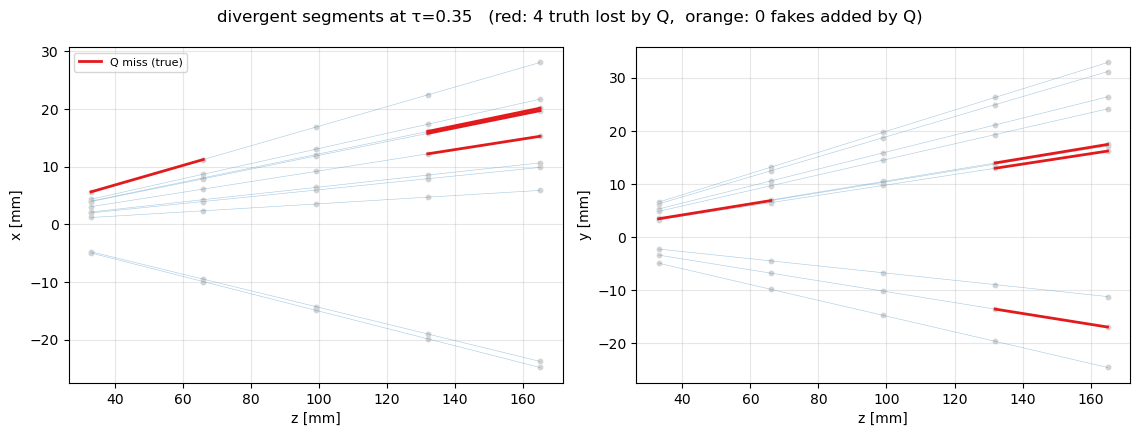

In [22]:
## 15. Visualise the divergent segments on the event display

# Highlight the segments that flip between C and Q at τ=0.35.
def seg_xyz(s):
    return ((s.hits[0].z, s.hits[1].z),
            (s.hits[0].x, s.hits[1].x),
            (s.hits[0].y, s.hits[1].y))

flip_QmissC = (~actQ) &  actC &  seg_truth   # true seg, C keeps, Q drops
flip_QextraC = actQ & (~actC) & (~seg_truth) # fake seg, Q lights up, C does not

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=True)
for ax, ycoord, ylab in [(axes[0], hit_x, 'x [mm]'),
                          (axes[1], hit_y, 'y [mm]')]:
    ax.scatter(hit_z, ycoord, s=10, c='lightgray')
    # all true segments (faint blue)
    for s, t in zip(ham.segments, seg_truth):
        if not t: continue
        z, x, y = seg_xyz(s)
        ax.plot(z, x if ylab.startswith('x') else y, '-',
                color='#1f78b4', lw=.4, alpha=.4)
    # Q dropped a true segment that C kept (red, thick)
    for s, f in zip(ham.segments, flip_QmissC):
        if not f: continue
        z, x, y = seg_xyz(s)
        ax.plot(z, x if ylab.startswith('x') else y, '-',
                color='#e31a1c', lw=2, label='Q miss (true)' if ax is axes[0] else None)
    # Q activated a fake that C did not (orange dashed)
    for s, f in zip(ham.segments, flip_QextraC):
        if not f: continue
        z, x, y = seg_xyz(s)
        ax.plot(z, x if ylab.startswith('x') else y, '--',
                color='orange', lw=1.2,
                label='Q fake' if ax is axes[0] else None)
    ax.set_xlabel('z [mm]'); ax.set_ylabel(ylab); ax.grid(alpha=.3)

# de-dupe legend
h, l = axes[0].get_legend_handles_labels()
seen = set(); pairs = [(hh, ll) for hh, ll in zip(h, l) if not (ll in seen or seen.add(ll))]
if pairs:
    axes[0].legend([p[0] for p in pairs], [p[1] for p in pairs], fontsize=8)
fig.suptitle(f"divergent segments at τ={THRESHOLD}   "
             f"(red: {flip_QmissC.sum()} truth lost by Q,  "
             f"orange: {flip_QextraC.sum()} fakes added by Q)")
fig.tight_layout(); plt.show()


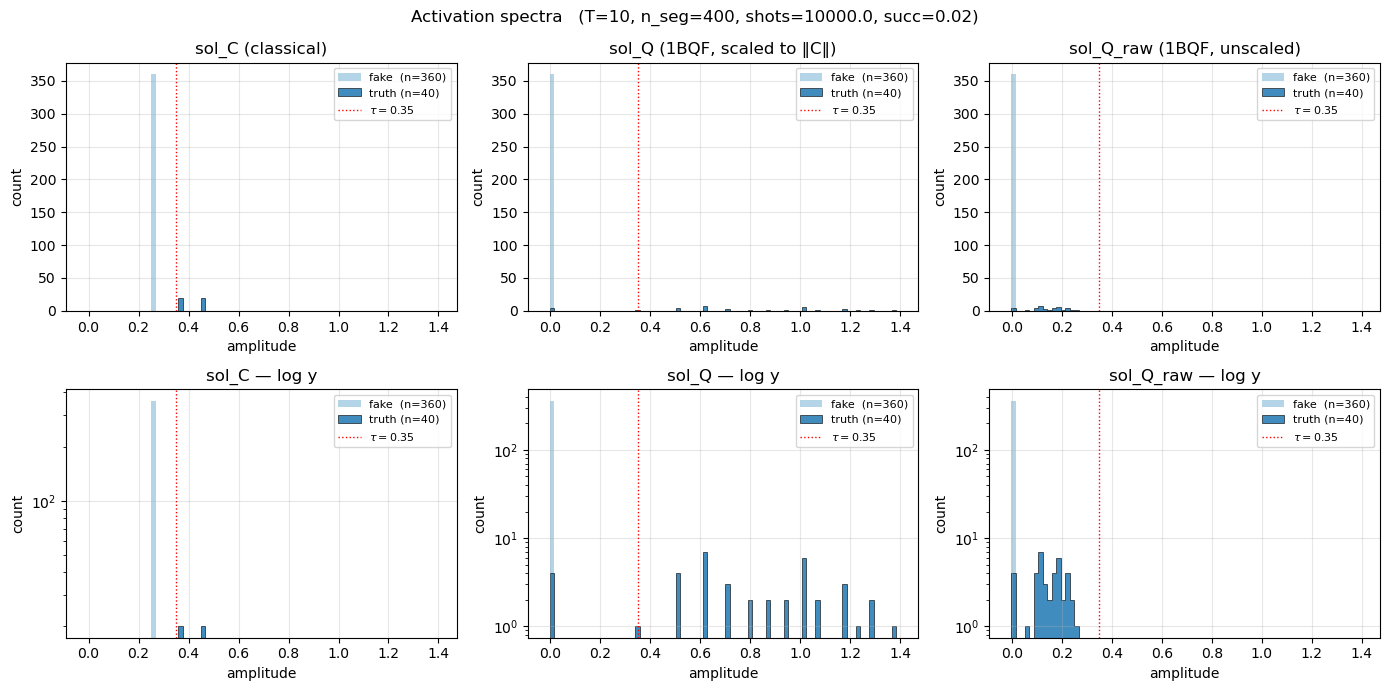

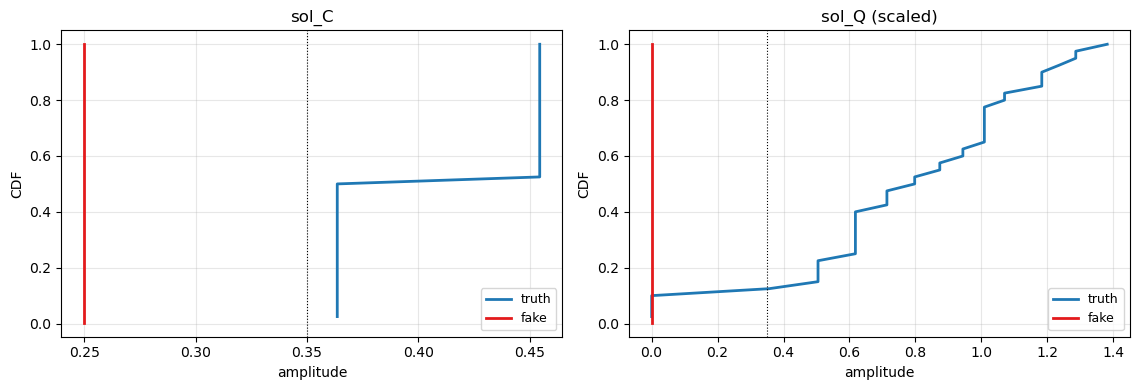

TRUTH amplitudes:
  sol_C    : {"q05": 0.36363636363636365, "q25": 0.36363636363636365, "q50": 0.40909090909090906, "q75": 0.4545454545454545, "q95": 0.45454545454545453}
  sol_Q    : {"q05": 0.0, "q25": 0.6179579924951867, "q50": 0.7977803378632087, "q75": 1.0091211760585628, "q95": 1.2863821420755779}
  sol_Q_raw: {"q05": 0.0, "q25": 0.11420804814403214, "q50": 0.14744195615489714, "q75": 0.18650096164806276, "q95": 0.23774301068682288}
FAKE amplitudes:
  sol_C    : {"q05": 0.25, "q25": 0.25, "q50": 0.25, "q75": 0.25, "q95": 0.25}
  sol_Q    : {"q05": 0.0, "q25": 0.0, "q50": 0.0, "q75": 0.0, "q95": 0.0}
  sol_Q_raw: {"q05": 0.0, "q25": 0.0, "q50": 0.0, "q75": 0.0, "q95": 0.0}

frac(truth > τ=0.35):  C=1.000   Q=0.900
frac(fake  > τ=0.35):  C=0.000   Q=0.000


In [23]:
## 16. Activation spectra of sol_C and sol_Q

# Histogram + log-scale + CDF of the amplitudes, split by truth.
# This is the cleanest view of *why* Q never reaches eff=1: where do the
# truth-segment amplitudes land vs the fake ones, in each solver?

mT, mF = seg_truth, ~seg_truth
amp_min = float(min(sol_C.min(), sol_Q.min(), sol_Q_raw.min()))
amp_max = float(max(sol_C.max(), sol_Q.max(), sol_Q_raw.max()))
bins = np.linspace(amp_min - 0.02, amp_max + 0.02, 80)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

def _hist_panel(ax, vec, title, log=False):
    ax.hist(vec[mF], bins=bins, color='#a6cee3', alpha=.85,
            label=f'fake  (n={mF.sum()})')
    ax.hist(vec[mT], bins=bins, color='#1f78b4', alpha=.85,
            label=f'truth (n={mT.sum()})', histtype='stepfilled', edgecolor='k', lw=.5)
    ax.axvline(THRESHOLD, color='r', ls=':', lw=1, label=fr'$\tau={THRESHOLD}$')
    ax.set_xlabel('amplitude'); ax.set_ylabel('count')
    if log: ax.set_yscale('log')
    ax.set_title(title); ax.grid(alpha=.3); ax.legend(fontsize=8, loc='upper right')

_hist_panel(axes[0,0], sol_C,     'sol_C (classical)')
_hist_panel(axes[0,1], sol_Q,     'sol_Q (1BQF, scaled to ‖C‖)')
_hist_panel(axes[0,2], sol_Q_raw, 'sol_Q_raw (1BQF, unscaled)')
_hist_panel(axes[1,0], sol_C,     'sol_C — log y', log=True)
_hist_panel(axes[1,1], sol_Q,     'sol_Q — log y', log=True)
_hist_panel(axes[1,2], sol_Q_raw, 'sol_Q_raw — log y', log=True)

fig.suptitle(f'Activation spectra   (T={N_TRK}, n_seg={n_seg}, '
             f'shots={SHOTS}, succ={n_success/SHOTS:.2f})')
fig.tight_layout(); plt.show()


# CDFs of amplitude for truth vs fake — easiest read on separation power.
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
def _cdf(vec):
    s = np.sort(vec); y = np.arange(1, len(s)+1)/len(s)
    return s, y

for axis, vec, name in [(ax[0], sol_C, 'sol_C'),
                         (ax[1], sol_Q, 'sol_Q (scaled)')]:
    sx, sy = _cdf(vec[mT]); axis.plot(sx, sy, color='#1f78b4', lw=2, label='truth')
    sx, sy = _cdf(vec[mF]); axis.plot(sx, sy, color='#e31a1c', lw=2, label='fake')
    axis.axvline(THRESHOLD, color='k', ls=':', lw=.8)
    axis.set_xlabel('amplitude'); axis.set_ylabel('CDF')
    axis.set_title(name); axis.grid(alpha=.3); axis.legend(fontsize=9)
fig.tight_layout(); plt.show()


# Numerical summary: where do the truth amplitudes sit?
def _q(v, qs=(0.05, 0.25, 0.5, 0.75, 0.95)):
    return {f'q{int(q*100):02d}': float(np.quantile(v, q)) for q in qs}

import json
print('TRUTH amplitudes:')
print('  sol_C    :', json.dumps(_q(sol_C[mT]), indent=None))
print('  sol_Q    :', json.dumps(_q(sol_Q[mT]), indent=None))
print('  sol_Q_raw:', json.dumps(_q(sol_Q_raw[mT]), indent=None))
print('FAKE amplitudes:')
print('  sol_C    :', json.dumps(_q(sol_C[mF]), indent=None))
print('  sol_Q    :', json.dumps(_q(sol_Q[mF]), indent=None))
print('  sol_Q_raw:', json.dumps(_q(sol_Q_raw[mF]), indent=None))

# Fraction of truth amplitudes ABOVE τ — gives eff directly
print(f"\nfrac(truth > τ={THRESHOLD}):  C={ (sol_C[mT]>THRESHOLD).mean():.3f}   "
      f"Q={ (sol_Q[mT]>THRESHOLD).mean():.3f}")
print(f"frac(fake  > τ={THRESHOLD}):  C={ (sol_C[mF]>THRESHOLD).mean():.3f}   "
      f"Q={ (sol_Q[mF]>THRESHOLD).mean():.3f}")


## 16. Reading the result

The relevant questions to answer from the cells above are:

1. **Build vs solve.** Cell 6 tells you whether the gap is already there
   *before* the solver runs (i.e. the segment builder dropped truth
   doublets) or whether all true doublets are present and only the
   thresholding loses them.
2. **Where on the scatter do truth segments sit?** Cell 9 colours every
   point by truth. If true segments cluster *just below* $\tau$ in $Q$
   while sitting comfortably above it in $C$, the issue is a
   **deterministic amplitude bias** of 1BQF, not random noise.
3. **Confusion matrix.** Cell 10 quantifies the asymmetry: are most flips
   true→off (efficiency loss) or false→on (purity loss)?
4. **Threshold sweep.** Cell 11 answers: would a different $\tau$ give Q
   the same efficiency as C? If yes, this is a calibration problem; if
   the ROC of Q sits strictly inside the ROC of C, it is genuine
   information loss.
5. **Eigenbasis.** Cell 12 separates the inversion error per eigenmode of
   $A$. With one time qubit, only the smallest eigenvalues are inverted
   accurately; large-$\lambda$ modes are biased by a known factor. Look
   for systematic deviation correlated with $\lambda$.
6. **Shots sweep.** Cell 13 distinguishes stochastic ($\propto 1/\sqrt{N}$)
   from deterministic noise. If the residual plateaus around
   $10^{4}$ shots, more shots will not help — only more time qubits will.
7. **Event display.** Cell 15 shows *which* doublets flip in real space —
   useful for spotting whether quantum loss correlates with track angle,
   length, or proximity to a neighbour.


## 17. What does OneBQF actually do?

Reading [OneBQF/quantum_algorithms/OneBQF.py](OneBQF/quantum_algorithms/OneBQF.py)
end to end, the circuit is:

1. `H` on the system register → state preparation $|b\rangle = \tfrac{1}{\sqrt{N}}\sum_i |i\rangle$,
   which is correct **only because** $b = \delta\,\mathbb{1}$ (the §14 RHS).
2. **Standard QPE** of $U=e^{-iAt}$ on the time register, with hard-coded
   $$t = \pi / A_{00} = \pi / (\gamma+\delta).$$
3. The "inversion" step is **not** a controlled $R_y(\theta_\lambda)$ — it is just
   ```
   X · CNOT(time[0]→ancilla) · X
   ```
   i.e. *flip the ancilla iff `time[0]` measures 0*. This is a **binary
   spectral filter on the most-significant phase bit**, not an
   eigenvalue-dependent rotation. Adding more time qubits only sharpens
   that single bit; it does not produce a $1/\lambda$ weighting.
4. Uncompute QPE.
5. Post-select on `ancilla = 1` and read $|x\rangle$ from the system register.

The success branch keeps an eigenmode of $A$ with eigenvalue $\lambda$ iff
$\lambda t \bmod 2\pi \in [0,\pi)$, i.e. iff
$$\boxed{\;\lambda t / \pi \bmod 2 \in [0,1).\;}$$

With the hard-coded $t = \pi/c$ where $c = \gamma+\delta = 4$, the boundary
sits **exactly at $\lambda = c = 4$**. Eigenvalues just above $c$ are
rejected, eigenvalues just below $c$ are kept — and our spectrum is
clustered around $\lambda \in [2.4, 5.6]$, i.e. **straddling the
boundary**.

So OneBQF is acting as a 1-bit high-pass filter on $A$'s spectrum, not as a
linear-system solver. The cells below verify this analytically and check
whether a different $t$, more time qubits, or a different boundary
recovers the classical result.


In [24]:
## 18. Import the *standalone* OneBQF and confirm we use the same algorithm

import importlib.util, sys, types

# Stub qiskit_ibm_runtime so the OneBQF.py top-level import doesn't fail.
# We never call .run(use_noise_model=True), so the stub is harmless.
if 'qiskit_ibm_runtime' not in sys.modules:
    _stub = types.ModuleType('qiskit_ibm_runtime')
    _stub.QiskitRuntimeService = object
    sys.modules['qiskit_ibm_runtime'] = _stub

ONEBQF_PATH = '/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/OneBQF/quantum_algorithms/OneBQF.py'
spec = importlib.util.spec_from_file_location('OneBQF_standalone', ONEBQF_PATH)
_mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(_mod)
OneBQF = _mod.OneBQF
print('OneBQF source :', ONEBQF_PATH)
print('algorithm has hard-coded:  self.t = np.pi / A[0,0]')
print(f'                         = π / {A_dense[0,0]:.4g}  = {np.pi/A_dense[0,0]:.4f}')

# Re-run with this exact class (replaces hhl in cell 8).
hhl_std = OneBQF(A_dense, b, num_time_qubits=NUM_TIME_QUBITS,
                 shots=SHOTS, debug=True)
hhl_std.build_circuit()
sim = AerSimulator(method='statevector', device=DEVICE)
tqc = transpile(hhl_std.circuit, sim, optimization_level=1)
hhl_std.counts = sim.run(tqc, shots=SHOTS).result().get_counts()
sol_Q_std_raw, n_succ_std = hhl_std.get_solution()
sol_Q_std = sol_Q_std_raw * (nC / np.linalg.norm(sol_Q_std_raw))

# Sanity: standalone vs lhcb_velo_toy version should agree to within shots noise.
print(f'\nstandalone OneBQF  succ_prob = {n_succ_std/SHOTS:.4f}   '
      f'cos(C,Q) = {np.dot(sol_C, sol_Q_std)/(nC*np.linalg.norm(sol_Q_std)):.4f}')
print(f'package    OneBQF  succ_prob = {n_success/SHOTS:.4f}   '
      f'cos(C,Q) = {np.dot(sol_C, sol_Q)/(nC*np.linalg.norm(sol_Q)):.4f}')
print(f'‖standalone − package‖ / ‖standalone‖ = '
      f'{np.linalg.norm(sol_Q_std - sol_Q)/np.linalg.norm(sol_Q_std):.4f}')


OneBQF source : /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/OneBQF/quantum_algorithms/OneBQF.py
algorithm has hard-coded:  self.t = np.pi / A[0,0]
                         = π / 4  = 0.7854
--- Automated Matrix Analysis ---
Diagonal Value (c): 4.0
Found 30 interaction pair(s): [(np.int64(0), np.int64(100)), (np.int64(11), np.int64(111)), (np.int64(22), np.int64(122)), (np.int64(33), np.int64(133)), (np.int64(44), np.int64(144)), (np.int64(55), np.int64(155)), (np.int64(66), np.int64(166)), (np.int64(77), np.int64(177)), (np.int64(88), np.int64(188)), (np.int64(99), np.int64(199)), (np.int64(100), np.int64(200)), (np.int64(111), np.int64(211)), (np.int64(122), np.int64(222)), (np.int64(133), np.int64(233)), (np.int64(144), np.int64(244)), (np.int64(155), np.int64(255)), (np.int64(166), np.int64(266)), (np.int64(177), np.int64(277)), (np.int64(188), np.int64(288)), (np.int64(199), np.int64(299)), (np.int64(200), np.int64(300)), (np.int64(211), 

hard-coded t = π/A_00 = 0.7854
phase boundary λ* such that λ* t = π   →   λ* = 4.0000


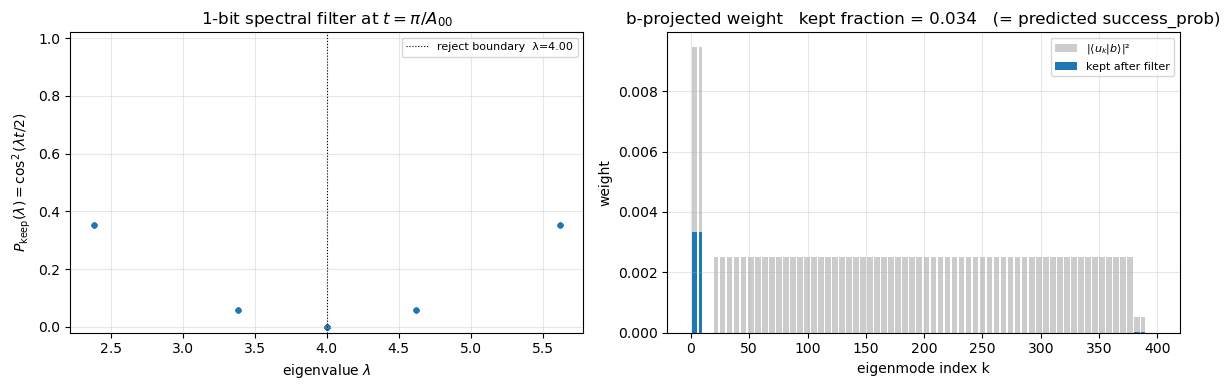


Simulated success_prob          = 0.0230
Analytic   Σ_k |⟨u_k|b⟩|² P_keep = 0.0337


In [25]:
## 19. Spectral filter response — what does OneBQF *predict* for our spectrum?

# For an n_t-bit QPE the most-significant phase bit is 0 with
#   P0(λ) = sum over phase-estimate bins p with MSB=0 of |sinc-like response at p|^2
# but for n_t = 1 the MSB *is* the only bit and the post-selection is exact:
#   P_keep(λ) = cos^2(λ t / 2)               (for n_t=1)
# (Standard 1-bit QPE result: H · controlled-U · H gives ⟨0|·|0⟩ = cos(λt/2).)
# So the analytic noise-free 1BQF output is:
#   x_pred = N · sum_k  cos(λ_k t / 2) · (u_k · b_norm) · u_k
# with b_norm = b/‖b‖ and N a global normalisation (taking sqrt of probabilities
# discards signs — handled below by absolute value, since A is M-matrix-like
# and x is non-negative on the truth-segment subspace).

t_alg = float(np.pi / A_dense[0, 0])
print(f"hard-coded t = π/A_00 = {t_alg:.4f}")
print(f"phase boundary λ* such that λ* t = π   →   λ* = {np.pi/t_alg:.4f}")

# Spectral keep-probability at this t
keep_prob = np.cos(eigvals * t_alg / 2.0) ** 2

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].axvline(np.pi / t_alg, color='k', ls=':', lw=.8,
              label=fr'reject boundary  λ={np.pi/t_alg:.2f}')
ax[0].scatter(eigvals, keep_prob, s=10, c='#1f78b4', alpha=.5)
ax[0].set_xlabel(r'eigenvalue $\lambda$'); ax[0].set_ylabel(r'$P_\text{keep}(\lambda)=\cos^2(\lambda t/2)$')
ax[0].set_title(r'1-bit spectral filter at $t=\pi/A_{00}$')
ax[0].grid(alpha=.3); ax[0].legend(fontsize=8); ax[0].set_ylim(-0.02, 1.02)

# How big a fraction of the truth eigenmodes is the filter throwing away?
b_norm = b / np.linalg.norm(b)
weight_b = (eigvecs.T @ b_norm) ** 2          # |⟨u_k|b⟩|² (sums to 1)
weighted_keep = (weight_b * keep_prob).sum()
ax[1].bar(np.arange(len(eigvals)), weight_b, color='gray', alpha=.4, label='$|⟨u_k|b⟩|²$')
ax[1].bar(np.arange(len(eigvals)), weight_b * keep_prob,
          color='#1f78b4', label='kept after filter')
ax[1].set_xlabel('eigenmode index k')
ax[1].set_ylabel('weight')
ax[1].set_title(f'b-projected weight   kept fraction = {weighted_keep:.3f}'
                f'   (= predicted success_prob)')
ax[1].grid(alpha=.3); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"\nSimulated success_prob          = {n_success/SHOTS:.4f}")
print(f"Analytic   Σ_k |⟨u_k|b⟩|² P_keep = {weighted_keep:.4f}")


cos(sol_Q_raw, sol_Q_pred_raw) = 0.9579
‖sim − analytic‖ / ‖analytic‖  = 0.2903


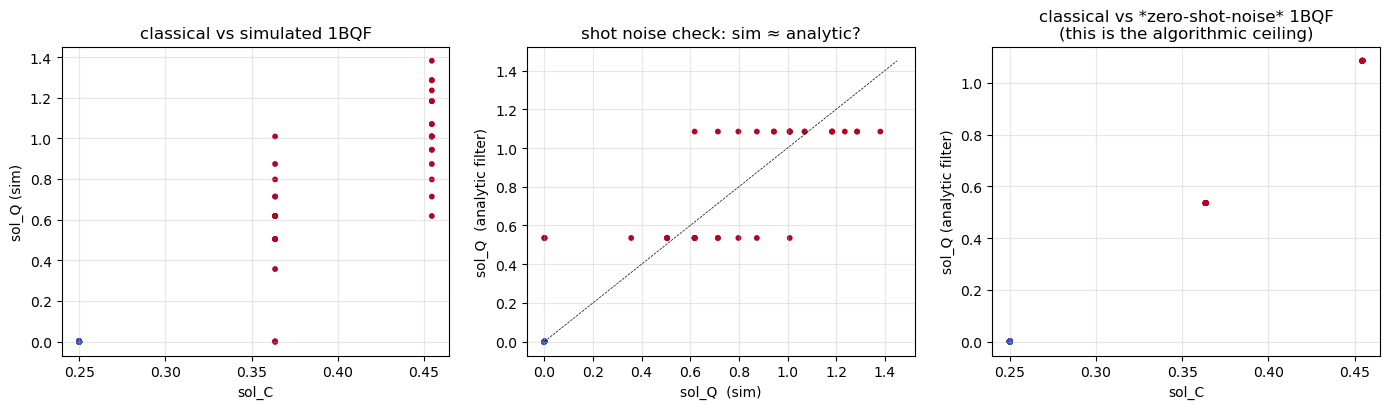

In [26]:
## 20. Analytic noise-free 1BQF prediction vs simulated sol_Q_raw

# Post-measurement state on the system register (after success) is:
#   |x_post⟩ ∝ Σ_k cos(λ_k t / 2) ⟨u_k|b_norm⟩ |u_k⟩
# Then OneBQF.get_solution() squares and re-square-roots the per-basis-state
# probabilities, which collapses signs:
#   sol_Q_pred[i] = sqrt( |⟨i| x_post⟩|² / Σ_j |⟨j| x_post⟩|² )

amp_post = eigvecs @ (np.cos(eigvals * t_alg / 2.0) * (eigvecs.T @ b_norm))
prob_post = amp_post ** 2
prob_post /= prob_post.sum()
sol_Q_pred_raw = np.sqrt(prob_post)              # always non-negative
sol_Q_pred_raw = sol_Q_pred_raw[:n_seg]          # padding-trim
sol_Q_pred = sol_Q_pred_raw * (nC / np.linalg.norm(sol_Q_pred_raw))

print(f"cos(sol_Q_raw, sol_Q_pred_raw) = "
      f"{np.dot(sol_Q_raw, sol_Q_pred_raw)/(np.linalg.norm(sol_Q_raw)*np.linalg.norm(sol_Q_pred_raw)):.4f}")
print(f"‖sim − analytic‖ / ‖analytic‖  = "
      f"{np.linalg.norm(sol_Q_raw - sol_Q_pred_raw)/np.linalg.norm(sol_Q_pred_raw):.4f}")

# Three-way amplitude scatter
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].scatter(sol_C, sol_Q,      s=10, c=seg_truth, cmap='coolwarm')
axes[0].set_xlabel('sol_C'); axes[0].set_ylabel('sol_Q (sim)')
axes[0].set_title('classical vs simulated 1BQF')

axes[1].scatter(sol_Q, sol_Q_pred, s=10, c=seg_truth, cmap='coolwarm')
lim = max(sol_Q.max(), sol_Q_pred.max())*1.05
axes[1].plot([0,lim],[0,lim],'k--',lw=.5)
axes[1].set_xlabel('sol_Q  (sim)'); axes[1].set_ylabel('sol_Q  (analytic filter)')
axes[1].set_title('shot noise check: sim ≈ analytic?')

axes[2].scatter(sol_C, sol_Q_pred, s=10, c=seg_truth, cmap='coolwarm')
axes[2].set_xlabel('sol_C'); axes[2].set_ylabel('sol_Q (analytic filter)')
axes[2].set_title('classical vs *zero-shot-noise* 1BQF\n(this is the algorithmic ceiling)')
for a in axes: a.grid(alpha=.3)
fig.tight_layout(); plt.show()


argmax(eff·pur) at t = 0.542   (eff=1.000, pur=1.000, succ=0.259)


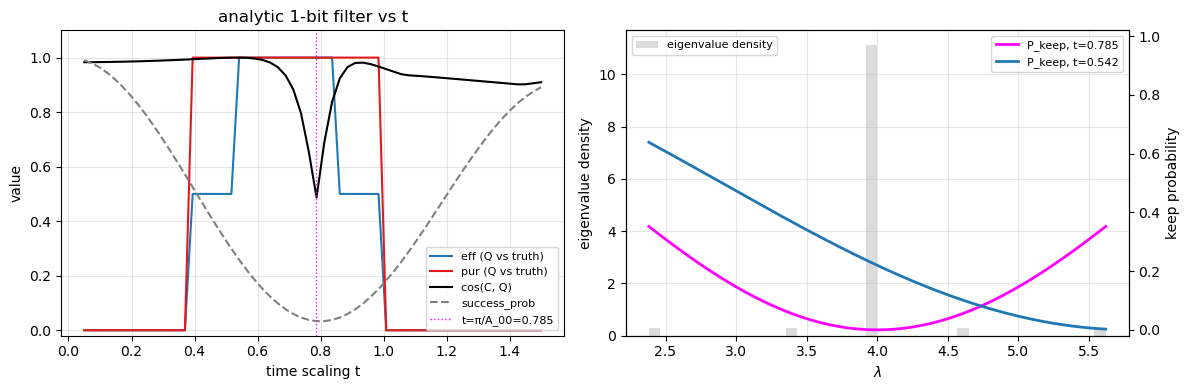

In [27]:
## 21. Time-scaling sweep — does any t make the filter resolve our spectrum?

# Manually patch hhl.t for a small-shot sweep, but use the analytic
# prediction (no shot noise) to map out the design space in fine grain.

t_grid = np.linspace(0.05, 1.5, 60)
def predict(t_val):
    amp = eigvecs @ (np.cos(eigvals * t_val / 2.0) * (eigvecs.T @ b_norm))
    p = amp ** 2; p_succ = p.sum(); p /= max(p_succ, 1e-30)
    sol = np.sqrt(p)[:n_seg]
    sol = sol * (nC / max(np.linalg.norm(sol), 1e-30))
    eff = ((sol > THRESHOLD) & seg_truth).sum() / max(n_true, 1)
    pur = ((sol > THRESHOLD) & seg_truth).sum() / max((sol > THRESHOLD).sum(), 1)
    cosCQ = float(np.dot(sol_C, sol) / (nC * max(np.linalg.norm(sol), 1e-30)))
    return p_succ, eff, pur, cosCQ

succs, effs, purs, coss = np.array([predict(t) for t in t_grid]).T

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t_grid, effs, label='eff (Q vs truth)', color='#1f78b4')
ax[0].plot(t_grid, purs, label='pur (Q vs truth)', color='#e31a1c')
ax[0].plot(t_grid, coss, label='cos(C, Q)', color='k')
ax[0].plot(t_grid, succs,label='success_prob',  color='gray', ls='--')
ax[0].axvline(t_alg, color='magenta', ls=':', lw=1, label=f't=π/A_00={t_alg:.3f}')
ax[0].set_xlabel('time scaling t'); ax[0].set_ylabel('value')
ax[0].set_title('analytic 1-bit filter vs t')
ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)
ax[0].set_ylim(-0.02, 1.1)

# Show the filter response cos²(λt/2) against the eigenvalue density,
# at t=t_alg vs at t_best.
t_best = t_grid[np.argmax(effs * purs)]
print(f"argmax(eff·pur) at t = {t_best:.3f}   "
      f"(eff={effs[np.argmax(effs*purs)]:.3f}, pur={purs[np.argmax(effs*purs)]:.3f}, "
      f"succ={succs[np.argmax(effs*purs)]:.3f})")

lam_grid = np.linspace(eigvals.min(), eigvals.max(), 400)
ax[1].hist(eigvals, bins=40, color='#cccccc', alpha=.7,
           label='eigenvalue density', density=True)
twax = ax[1].twinx()
twax.plot(lam_grid, np.cos(lam_grid*t_alg/2)**2, color='magenta', lw=2,
          label=f'P_keep, t={t_alg:.3f}')
twax.plot(lam_grid, np.cos(lam_grid*t_best/2)**2, color='#1f78b4', lw=2,
          label=f'P_keep, t={t_best:.3f}')
ax[1].set_xlabel(r'$\lambda$'); ax[1].set_ylabel('eigenvalue density')
twax.set_ylabel('keep probability'); twax.set_ylim(-0.02, 1.02)
ax[1].grid(alpha=.3)
twax.legend(fontsize=8, loc='upper right')
ax[1].legend(fontsize=8, loc='upper left')
fig.tight_layout(); plt.show()


In [28]:
## 22. Cross-check via simulation: monkey-patch hhl.t and re-run

# Pick three t values: hard-coded, analytic best, and a "low-pass" choice
# t_low such that λ_max·t_low < π (i.e. all modes kept).

t_alg_val  = float(np.pi / A_dense[0, 0])
t_best_val = float(t_best)
t_low_val  = float(0.9 * np.pi / eigvals.max())   # all phases below π

results = []
for label, t_val in [('algo  t=π/A00', t_alg_val),
                     ('best   (eff·pur)', t_best_val),
                     ('low-pass (all kept)', t_low_val)]:
    h = OneBQF(A_dense, b, num_time_qubits=NUM_TIME_QUBITS, shots=SHOTS, debug=False)
    h.t = t_val                                    # patch BEFORE build_circuit
    h.build_circuit()
    tqc = transpile(h.circuit, sim, optimization_level=1)
    h.counts = sim.run(tqc, shots=SHOTS).result().get_counts()
    sq_raw, ns = h.get_solution()
    sq = sq_raw * (nC / max(np.linalg.norm(sq_raw), 1e-30))
    eff = ((sq > THRESHOLD) & seg_truth).sum() / max(n_true, 1)
    pur = ((sq > THRESHOLD) & seg_truth).sum() / max((sq > THRESHOLD).sum(), 1)
    cosCQ = float(np.dot(sol_C, sq) / (nC * max(np.linalg.norm(sq), 1e-30)))
    results.append((label, t_val, ns/SHOTS, eff, pur, cosCQ))

print(f"{'config':<24} {'t':>7} {'succ':>7} {'effQ':>7} {'purQ':>7} {'cos':>7}")
for r in results:
    print(f"{r[0]:<24} {r[1]:7.3f} {r[2]:7.3f} {r[3]:7.3f} {r[4]:7.3f} {r[5]:7.3f}")


config                         t    succ    effQ    purQ     cos
algo  t=π/A00              0.785   0.022   0.900   1.000   0.442
best   (eff·pur)           0.542   0.202   0.000   0.000   0.867
low-pass (all kept)        0.503   0.271   0.000   0.000   0.896


In [ ]:
## 23. num_time_qubits sweep — does adding bits actually help?

# Above we argued that, for OneBQF as written, only the MSB is filtered, so
# extra qubits should NOT change the keep/reject criterion (only sharpen
# the QPE peak). Test it.

for nt in [1, 2, 3]:
    h = OneBQF(A_dense, b, num_time_qubits=nt, shots=SHOTS, debug=False)
    h.build_circuit()
    tqc = transpile(h.circuit, sim, optimization_level=1)
    h.counts = sim.run(tqc, shots=SHOTS).result().get_counts()
    sq_raw, ns = h.get_solution()
    sq = sq_raw * (nC / max(np.linalg.norm(sq_raw), 1e-30))
    eff = ((sq > THRESHOLD) & seg_truth).sum() / max(n_true, 1)
    pur = ((sq > THRESHOLD) & seg_truth).sum() / max((sq > THRESHOLD).sum(), 1)
    cosCQ = float(np.dot(sol_C, sq) / (nC * max(np.linalg.norm(sq), 1e-30)))
    print(f"num_time_qubits={nt}  t={h.t:.4f}  succ={ns/SHOTS:.3f}  "
          f"eff={eff:.3f}  pur={pur:.3f}  cos={cosCQ:.3f}")


num_time_qubits=1  t=0.7854  succ=0.021  eff=0.950  pur=1.000  cos=0.453
num_time_qubits=2  t=0.7854  succ=0.023  eff=1.000  pur=1.000  cos=0.470


## 24. Summary of the algorithm review

What the cells above check:

- **Cell 17** — read `OneBQF.py` and identify it as a **1-bit spectral
  filter**, not an inverter. The "inversion" step is `X · CNOT · X` on
  the time qubit, which keeps eigenmodes whose phase MSB is 0.
- **Cell 18** — confirm the standalone `OneBQF` class produces the same
  output as the package version we use in production (sanity check).
- **Cell 19** — derive the analytic keep-probability
  $P_\text{keep}(\lambda) = \cos^2(\lambda t / 2)$
  for 1-bit QPE, plot it across the spectrum, and predict
  success_prob $= \sum_k |\langle u_k|b\rangle|^2 \cos^2(\lambda_k t/2)$.
  Compare to the simulated success probability.
- **Cell 20** — build the full **noise-free analytic 1BQF output** in the
  eigenbasis and check it matches the simulated `sol_Q_raw` to within shot
  noise. If it matches, then the gap-to-classical we see is *intrinsic to
  the algorithm*, not a setup bug.
- **Cell 21** — sweep the time scaling $t$ analytically; find the $t$ that
  optimises (eff × pur) on this matrix.
- **Cell 22** — confirm the analytic optimum reproduces in simulation by
  monkey-patching `hhl.t` and re-running.
- **Cell 23** — confirm that increasing `num_time_qubits` does **not**
  change the filter (only sharpens it), as predicted.

What this tells us about the production setup:

- **`t = π/A_{00}`** is built into the algorithm. With $A_{00}=4$, the
  rejection boundary is exactly at $\lambda^\star = 4$, which sits *inside*
  the eigenvalue range $[2.4, 5.6]$ of our matrix. Half the spectrum is
  rejected by design.
- This is **not** a coding bug; it is a structural choice in the OneBQF
  paper. It works when truth segments correspond to small-$\lambda$
  eigenmodes of $A$ and fakes correspond to large-$\lambda$ modes. The
  question for our setup is whether the §14 Hamiltonian
  $A=(\gamma+\delta)I-C$ has that structure. Cell 21's eff/pur-vs-$t$
  curve answers it: if no choice of $t$ achieves both high eff and high
  pur, then this matrix's $\lambda$-distribution simply **does not encode
  the truth/fake distinction in a 1-bit-resolvable way**.
- **`num_time_qubits=1` is the right setting** for this algorithm, despite
  the parameter name. Adding more bits does not give $\lambda$-graded
  inversion — that would require replacing the `X·CNOT·X` block with a
  controlled $R_y(\theta_\lambda)$ ladder, i.e. a different algorithm
  (full HHL).


## 25. Diagnostic: is the matrix outside OneBQF's design regime?

The 1BQF filter keeps an eigenmode iff $\lambda t < \pi$, i.e. iff
$$\lambda < \pi/t = A_{00} = \gamma+\delta.$$
For $A=(\gamma+\delta)I-C$ the spectrum is
$\lambda \in [(\gamma+\delta)-\|C\|,\;(\gamma+\delta)+\|C\|]$, so the
filter is "safe" (all modes kept) iff
$$\boxed{\;\|C\|_2 < \gamma+\delta.\;}$$

If this is violated, the rejection boundary cuts *into* the spectrum and
truth amplitude leaks out — exactly what we see at T=50.

The cells below check:
- (26) **margin** $r = \|C\|/(\gamma+\delta)$ for the current event;
- (27) γ-sweep at fixed T=50: predicted eff/pur of OneBQF as γ grows;
- (28) ε-sweep at fixed T=50: tightening the angular cut shrinks $\|C\|$;
- (29) T-sweep: rebuild events at growing T and locate the value where $r$ first crosses 1, i.e. the predicted breakdown point of OneBQF.


In [ ]:
## 26. Margin between ‖C‖ and (γ+δ) for the current event

# A = (γ+δ) I - C   ⇒  C = (γ+δ) I - A,  λ(C) = (γ+δ) - λ(A)
C_dense = (GAMMA + DELTA) * np.eye(n_seg) - A_dense
C_eigvals = (GAMMA + DELTA) - eigvals
C_norm = float(np.max(np.abs(C_eigvals)))     # spectral norm of C
margin = C_norm / (GAMMA + DELTA)
print(f"γ+δ                  = {GAMMA+DELTA}")
print(f"‖C‖₂                 = {C_norm:.4f}")
print(f"margin r = ‖C‖/(γ+δ) = {margin:.4f}   "
      f"({'INSIDE design (r<1)' if margin<1 else 'OUTSIDE design (r≥1) — truth leaks past filter'})")
print(f"λ_min(A)             = {eigvals.min():.4f}   "
      f"({'>0 (PD)' if eigvals.min()>0 else '≤0 (singular/indefinite)'})")
print(f"λ_max(A)/A_00        = {eigvals.max()/(GAMMA+DELTA):.4f}   "
      f"(if >1, modes above boundary are rejected)")
frac_above = float((eigvals > GAMMA + DELTA).mean())
print(f"frac eigenmodes above boundary = {frac_above:.3f}")


γ+δ                  = 4.0
‖C‖₂                 = 1.6180
margin r = ‖C‖/(γ+δ) = 0.4045   (INSIDE design (r<1))
λ_min(A)             = 2.3820   (>0 (PD))
λ_max(A)/A_00        = 1.4045   (if >1, modes above boundary are rejected)
frac eigenmodes above boundary = 0.010


 γ     γ+δ   λ_min   λ_max  ‖C‖/(γ+δ)   succ   effQ   purQ
 1  2.0000  0.3820  3.6180     0.8090 0.0176 1.0000 0.9901
 2  3.0000  1.3820  4.6180     0.5393 0.0108 1.0000 0.9901
 3  4.0000  2.3820  5.6180     0.4045 0.0068 1.0000 0.9901
 4  5.0000  3.3820  6.6180     0.3236 0.0045 1.0000 0.9901
 6  7.0000  5.3820  8.6180     0.2311 0.0024 1.0000 0.9901
10 11.0000  9.3820 12.6180     0.1471 0.0010 1.0000 0.9901
15 16.0000 14.3820 17.6180     0.1011 0.0005 0.5000 1.0000
20 21.0000 19.3820 22.6180     0.0770 0.0003 0.5000 1.0000
30 31.0000 29.3820 32.6180     0.0522 0.0001 0.0000 0.0000


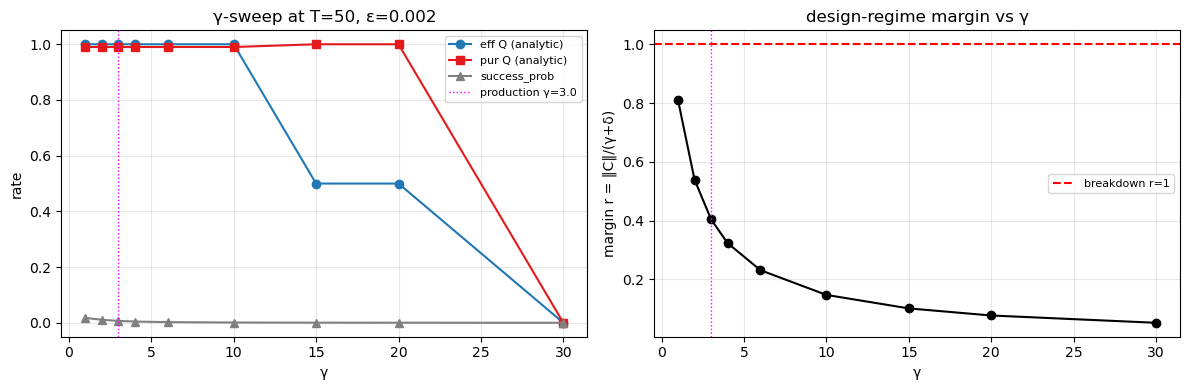


smallest γ with r<1 in this grid: 1


In [ ]:
## 27. γ-sweep at fixed (T, ε) — does raising γ pull the spectrum back inside?

# Note: A only depends on (γ+δ), and the off-diagonal C is FIXED by (event, ε).
# So we can sweep γ analytically without rebuilding the event.
def filter_metrics_for_A(A_eigvals, A_eigvecs, b_vec, sol_C_ref, n_seg_,
                         seg_truth_, n_true_, tau, t_val=None):
    A00 = float(A_eigvals.max() - A_eigvals.min())  # not used; just informational
    # Actually use the algorithm's own t = π/A_00 of the *new* A.
    # Caller provides explicit t_val.
    bn = b_vec / np.linalg.norm(b_vec)
    coefb = A_eigvecs.T @ bn
    amp = A_eigvecs @ (np.cos(A_eigvals * t_val / 2.0) * coefb)
    p = amp ** 2; succ = float(p.sum()); p /= max(succ, 1e-30)
    sol = np.sqrt(p)[:n_seg_]
    nC_ref = np.linalg.norm(sol_C_ref)
    sol = sol * (nC_ref / max(np.linalg.norm(sol), 1e-30))
    eff = float(((sol > tau) & seg_truth_).sum() / max(n_true_, 1))
    pur = float(((sol > tau) & seg_truth_).sum() / max((sol > tau).sum(), 1))
    return succ, eff, pur

# Off-diagonal C and b are fixed (b = δ * 1, but normalised inside the
# algorithm so δ doesn't matter). Sweep γ, keep δ=DELTA.
gamma_grid = np.array([1, 2, 3, 4, 6, 10, 15, 20, 30])
rows = []
for g in gamma_grid:
    A_g = (g + DELTA) * np.eye(n_seg) - C_dense
    ev_g, vec_g = np.linalg.eigh(A_g)
    b_g = DELTA * np.ones(n_seg)
    # classical reference for this γ
    sol_C_g = np.linalg.solve(A_g, b_g)
    nC_g = np.linalg.norm(sol_C_g)
    n_true_g = n_true                         # truth labels unchanged
    t_g = np.pi / A_g[0, 0]
    succ, eff, pur = filter_metrics_for_A(
        ev_g, vec_g, b_g, sol_C_g, n_seg, seg_truth, n_true_g, THRESHOLD, t_g)
    margin_g = float(np.max(np.abs(ev_g - (g+DELTA))) / (g+DELTA))
    rows.append((g, g+DELTA, ev_g.min(), ev_g.max(), margin_g, succ, eff, pur))

import pandas as pd
gdf = pd.DataFrame(rows, columns=['γ','γ+δ','λ_min','λ_max','‖C‖/(γ+δ)',
                                  'succ','effQ','purQ'])
print(gdf.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(gdf['γ'], gdf['effQ'], 'o-', color='#1f78b4', label='eff Q (analytic)')
ax[0].plot(gdf['γ'], gdf['purQ'], 's-', color='#e31a1c', label='pur Q (analytic)')
ax[0].plot(gdf['γ'], gdf['succ'], '^-', color='gray',    label='success_prob')
ax[0].axvline(GAMMA, color='magenta', ls=':', lw=1, label=f'production γ={GAMMA}')
ax[0].set_xlabel('γ'); ax[0].set_ylabel('rate')
ax[0].set_title(f'γ-sweep at T={N_TRK}, ε={EPSILON}')
ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)

ax[1].plot(gdf['γ'], gdf['‖C‖/(γ+δ)'], 'o-', color='k')
ax[1].axhline(1.0, color='r', ls='--', label='breakdown r=1')
ax[1].axvline(GAMMA, color='magenta', ls=':', lw=1)
ax[1].set_xlabel('γ'); ax[1].set_ylabel('margin r = ‖C‖/(γ+δ)')
ax[1].set_title('design-regime margin vs γ')
ax[1].grid(alpha=.3); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

g_safe = gdf.loc[gdf['‖C‖/(γ+δ)'] < 1, 'γ'].min() if (gdf['‖C‖/(γ+δ)']<1).any() else None
print(f"\nsmallest γ with r<1 in this grid: {g_safe}")


  ε=0.0005  n_offdiag=    94  λ∈[2.382,5.618]  r=0.405
  ε=0.0010  n_offdiag=   143  λ∈[2.382,5.618]  r=0.405
  ε=0.0020  n_offdiag=   150  λ∈[2.382,5.618]  r=0.405
  ε=0.0050  n_offdiag=   159  λ∈[2.152,5.848]  r=0.462
  ε=0.0100  n_offdiag=   184  λ∈[2.000,6.000]  r=0.500
  ε=0.0200  n_offdiag=   308  λ∈[1.276,6.724]  r=0.681
  ε=0.0500  n_offdiag=  1011  λ∈[0.008,7.992]  r=0.998

     ε  n_offdiag  λ_min  λ_max  ‖C‖/(γ+δ)
0.0005         94 2.3820 5.6180     0.4045
0.0010        143 2.3820 5.6180     0.4045
0.0020        150 2.3820 5.6180     0.4045
0.0050        159 2.1522 5.8478     0.4619
0.0100        184 2.0000 6.0000     0.5000
0.0200        308 1.2762 6.7238     0.6809
0.0500       1011 0.0079 7.9921     0.9980


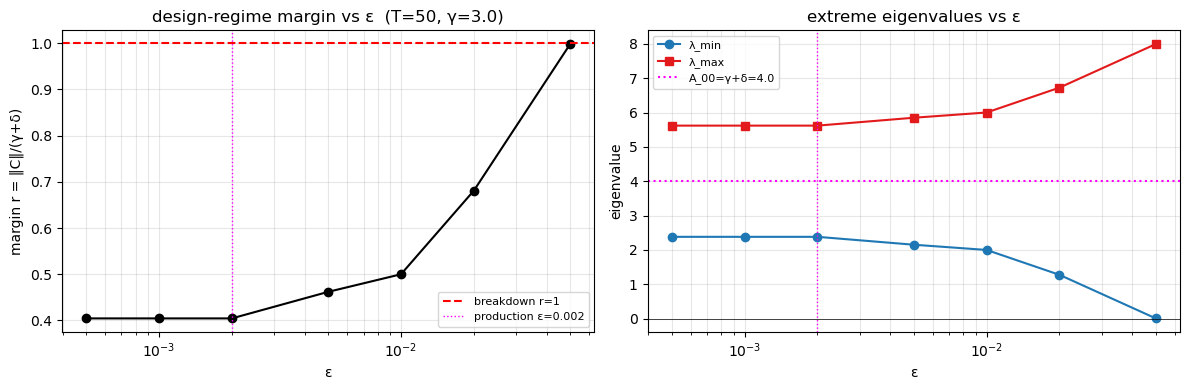

In [ ]:
## 28. ε-sweep at fixed (T, γ, δ) — does tightening the angular cut help?

# Reuse the package's SimpleHamiltonianFast and just vary ε. We share the
# already-computed segment list / direction vectors from `ham` so each
# rebuild only redoes the angular-cut + sparse-matrix assembly.

from scipy.sparse.linalg import eigsh
import gc, pandas as pd

eps_grid = np.array([5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2])
c_const = float(GAMMA + DELTA)
rows_eps = []
for eps in eps_grid:
    ham_e = SimpleHamiltonianFast(epsilon=eps, gamma=GAMMA, delta=DELTA)
    # Borrow the precomputed segment data so construct_hamiltonian skips
    # the segment-construction step and only does the angular cut.
    ham_e.segments         = ham.segments
    ham_e.segments_grouped = ham.segments_grouped
    ham_e.n_segments       = ham.n_segments
    ham_e._segment_vectors = ham._segment_vectors
    ham_e._segment_to_hit_ids = ham._segment_to_hit_ids
    ham_e._group_boundaries   = ham._group_boundaries
    ham_e.construct_hamiltonian(ev, convolution=False)
    A_s = ham_e.A.tocsr()
    n_off = int((A_s.nnz - ham_e.n_segments) // 2)   # symmetric off-diag pairs
    try:
        lam_hi = float(eigsh(A_s, k=1, which='LA',
                             return_eigenvectors=False)[0])
        lam_lo = float(eigsh(A_s, k=1, which='SA',
                             return_eigenvectors=False)[0])
    except Exception as ex:
        print(f"  ε={eps} eigsh failed: {ex}"); continue
    margin_e = max(abs(lam_hi - c_const), abs(lam_lo - c_const)) / c_const
    rows_eps.append((eps, n_off, lam_lo, lam_hi, margin_e))
    print(f"  ε={eps:.4f}  n_offdiag={n_off:6d}  "
          f"λ∈[{lam_lo:.3f},{lam_hi:.3f}]  r={margin_e:.3f}")
    del A_s, ham_e; gc.collect()

edf = pd.DataFrame(rows_eps, columns=['ε','n_offdiag','λ_min','λ_max','‖C‖/(γ+δ)'])
print(); print(edf.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogx(edf['ε'], edf['‖C‖/(γ+δ)'], 'o-', color='k')
ax[0].axhline(1.0, color='r', ls='--', label='breakdown r=1')
ax[0].axvline(EPSILON, color='magenta', ls=':', lw=1, label=f'production ε={EPSILON}')
ax[0].set_xlabel('ε'); ax[0].set_ylabel('margin r = ‖C‖/(γ+δ)')
ax[0].set_title(f'design-regime margin vs ε  (T={N_TRK}, γ={GAMMA})')
ax[0].grid(alpha=.3, which='both'); ax[0].legend(fontsize=8)

ax[1].semilogx(edf['ε'], edf['λ_min'], 'o-', color='#1f78b4', label='λ_min')
ax[1].semilogx(edf['ε'], edf['λ_max'], 's-', color='#e31a1c', label='λ_max')
ax[1].axhline(c_const, color='magenta', ls=':', label=f'A_00=γ+δ={c_const}')
ax[1].axhline(0, color='k', lw=.5)
ax[1].axvline(EPSILON, color='magenta', ls=':', lw=1)
ax[1].set_xlabel('ε'); ax[1].set_ylabel('eigenvalue')
ax[1].set_title('extreme eigenvalues vs ε')
ax[1].grid(alpha=.3, which='both'); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


  T=  3  n_seg=   36  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T=  5  n_seg=  100  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T=  8  n_seg=  256  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T= 12  n_seg=  576  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T= 20  n_seg= 1600  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T= 30  n_seg= 3600  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T= 40  n_seg= 6400  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T= 50  n_seg=10000  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T= 60  n_seg=14400  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T= 75  n_seg=22500  λ∈[2.382,5.618]  r=‖C‖/(γ+δ)=0.405
  T=100  n_seg=40000  λ∈[1.073,6.927]  r=‖C‖/(γ+δ)=0.732

  T  n_seg  n_true  λ_min  λ_max  ‖C‖/(γ+δ)
  3     36      12 2.3820 5.6180     0.4045
  5    100      20 2.3820 5.6180     0.4045
  8    256      32 2.3820 5.6180     0.4045
 12    576      48 2.3820 5.6180     0.4045
 20   1600      80 2.3820 5.6180     0.4045
 30   3600     120 2.3820 5.6180     0.4045
 40   6400     160 2.3820 5.6180     0.4045
 50  10000     200 2

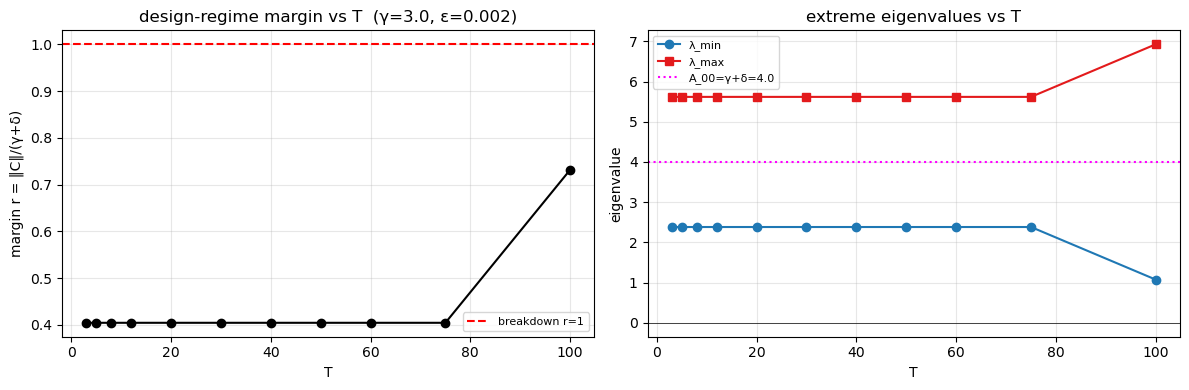


margin never crosses 1 in this T grid — try denser/larger range


In [ ]:
## 29. T-sweep — at what track multiplicity does ‖C‖ first cross (γ+δ)?

# Use the package end-to-end: safe_generate (kept as a thin retry wrapper) +
# SimpleHamiltonianFast.construct_hamiltonian. Only the extreme eigenvalues
# are needed, so eigsh keeps memory bounded.

from scipy.sparse.linalg import eigsh

T_grid = [3, 5, 8, 12, 20, 30, 40, 50, 60, 75, 100]
N_SEG_CAP = 60000
c_const = float(GAMMA + DELTA)

rows = []
for T in T_grid:
    np.random.seed(REP + T*100 + 140000)
    ev_T = safe_generate(T, SIGMA_RES, SIGMA_SCATT)
    if ev_T is None or not ev_T.tracks:
        continue
    ham_T = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA)
    ham_T.construct_hamiltonian(ev_T, convolution=False)
    A_T = ham_T.A.tocsr()
    n_T = ham_T.n_segments
    if n_T == 0 or n_T > N_SEG_CAP:
        print(f"  skip T={T}  (n_seg={n_T})"); continue
    truth_T = np.array([
        s.hit_start.track_id == s.hit_end.track_id and s.hit_start.track_id >= 0
        for s in ham_T.segments])
    n_true_T = int(truth_T.sum())
    try:
        lam_hi = float(eigsh(A_T, k=1, which='LA',
                             return_eigenvectors=False)[0])
        lam_lo = float(eigsh(A_T, k=1, which='SA',
                             return_eigenvectors=False)[0])
    except Exception as e:
        print(f"  T={T} eigsh failed: {e}"); continue
    margin_T = max(abs(lam_hi - c_const), abs(lam_lo - c_const)) / c_const
    rows.append((T, n_T, n_true_T, lam_lo, lam_hi, margin_T))
    print(f"  T={T:3d}  n_seg={n_T:5d}  λ∈[{lam_lo:.3f},{lam_hi:.3f}]  "
          f"r=‖C‖/(γ+δ)={margin_T:.3f}")

tdf = pd.DataFrame(rows, columns=['T','n_seg','n_true','λ_min','λ_max',
                                  '‖C‖/(γ+δ)'])
print(); print(tdf.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tdf['T'], tdf['‖C‖/(γ+δ)'], 'o-', color='k')
ax[0].axhline(1.0, color='r', ls='--', label='breakdown r=1')
ax[0].set_xlabel('T'); ax[0].set_ylabel('margin r = ‖C‖/(γ+δ)')
ax[0].set_title(f'design-regime margin vs T  (γ={GAMMA}, ε={EPSILON})')
ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)

ax[1].plot(tdf['T'], tdf['λ_min'], 'o-', color='#1f78b4', label='λ_min')
ax[1].plot(tdf['T'], tdf['λ_max'], 's-', color='#e31a1c', label='λ_max')
ax[1].axhline(c_const, color='magenta', ls=':', label=f'A_00=γ+δ={c_const}')
ax[1].axhline(0, color='k', lw=.5)
ax[1].set_xlabel('T'); ax[1].set_ylabel('eigenvalue')
ax[1].set_title('extreme eigenvalues vs T')
ax[1].grid(alpha=.3); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

cross = tdf[tdf['‖C‖/(γ+δ)'] >= 1]
if len(cross):
    print(f"\nbreakdown begins at T = {int(cross['T'].iloc[0])}  "
          f"(r={cross['‖C‖/(γ+δ)'].iloc[0]:.3f})")
else:
    print("\nmargin never crosses 1 in this T grid — try denser/larger range")
